In [1]:
import numpy as np 
from netCDF4 import Dataset
import os
import tensorflow as tf
import argparse
import pandas as pd
from tensorflow import keras

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import time
import matplotlib
import matplotlib.ticker as mticker
import warnings

%matplotlib inline

%load_ext autoreload
%autoreload 2

2025-08-15 14:49:51.240746: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX512_VNNI AVX512_BF16
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-15 14:49:51.668285: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# HOME = "/scistor/ivm/the410/"

HOME = "/home/thappe/" #snellius

In [4]:
os.chdir(f"{HOME}/HeaT")
#sys.path.append(os.path.expanduser('/home/thappe/HeaT'))

from HeaT.TFrecord_utils_ERA_v2 import *
from HeaT.reconstruction import *
from HeaT.clustering import Clustering

from HeaT.LatentSpace import *


## Get ERA5 heatwave means and cluster allocations



In [5]:
data_path = "/home/thappe/data/VAE_MODEL"

In [6]:
t2m_thermo_clustered = Clustering(t2m_name = "t2m_minus_thermo", 
                                  VAE_model = (128, f"{data_path}/VAE3D_3D_noRSDS_5d_TRANSFER_L128_B0.01_F4_AUGMENTED_final.h5"),
                                  data_path="/home/thappe/data/VAE_MODEL", 
                                  standardization_method="standardization_cut",
                                  cluster_model_name="GMM", 
                                  cluster_type="fit",
                                  cluster_k = 4)

heatwave_means = t2m_thermo_clustered.heatwave_means
heatwave_clusters = t2m_thermo_clustered.y_pred
heatwave_clusters_probs = t2m_thermo_clustered.y_pred_proba
heatwave_dates = t2m_thermo_clustered.heatwave_dates

loading GMM


2025-08-15 14:53:43.868700: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:267] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-08-15 14:53:43.868788: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (tcn710.local.snellius.surf.nl): /proc/driver/nvidia/version does not exist
2025-08-15 14:53:43.878614: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX512_VNNI AVX512_BF16
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [7]:
heatwave_means.shape

(739, 128)

In [8]:
heatwave_dates.shape

(739,)

In [71]:
class LatentSpaceAnalysis:
    def __init__(self, clustered,
                year_splits=[[1940,1970],[1990,2020]],
                top_N_nodes=10):
        
        #clustered information and encoded means
        self.clustered = clustered
        self.heatwave_means = clustered.heatwave_means
        self.heatwave_clusters = clustered.y_pred
        self.heatwave_dates = clustered.heatwave_dates
        
        #other parameters
        self.early = year_splits[0]
        self.late  = year_splits[1]
        self.N_nodes = top_N_nodes
        
        #call self to split heatwave means depending on year
        self.split_heatwave_means_year()
        
        #call self to split heatwave means depending on cluster
        self.split_heatwave_means_cluster()
        
        #function to calculate difference of cluster means given mean OR indidivudal heatwaves
        """
        - Als ik 1 heatwave sample neem (of mean van x-closest), hoe is de difference between die means
        en het Cluster waar ze belongen, en ook vergelijken met de andere Clusters. 
        
        - als ik 1 heatweave heb (of x-closest), en ik de top_nodes neem (self.heatwave_difference_top_nodes)
        en deze verander naar mean van een andere cluster bijv., ; wat gebeurt er met cluster assignment
        dus using self.clustered.predict(changed_item). EN wat gebeurt er met de reconstruction 
        dat moet ik nog ergens fixen ook, de VAE inladen en reconstructen (lukt dat op snellius...?)
        """

        
    def split_heatwave_means_year(self):
        heatwaves_early = []
        heatwaves_late = []

        for i in range(self.heatwave_means.shape[0]):
            year = self.heatwave_dates[i].year
            mean = heatwave_means.values[i, :]

            if year >= self.early[0] and year <= self.early[1] : #early cat
                heatwaves_early.append(mean)
            elif year >= self.late[0] and year <= self.late[1]: #late cat
                heatwaves_late.append(mean)
                
        self.heatwave_means_early = heatwaves_early
        self.heatwaves_means_late = heatwaves_late
        
        self.heatwaves_early_mean = np.mean(np.array(heatwaves_early), axis=0)
        self.heatwaves_late_mean = np.mean(np.array(heatwaves_late), axis=0)
        
        
    def split_heatwave_means_cluster(self):
        self.heatwave_means_per_cluster = {}
        self.heatwave_mean_of_cluster = {}

        for k in range(self.clustered.cluster_k):
            clusterID = k+1
            indices = np.where(self.heatwave_clusters==k)[0]
            heatwave_means_of_this_cluster = self.heatwave_means.to_numpy()[indices]
            self.heatwave_means_per_cluster[clusterID]=(heatwave_means_of_this_cluster)

            mean_of_cluster = np.mean(heatwave_means_of_this_cluster, axis=0)
            self.heatwave_mean_of_cluster[clusterID]=mean_of_cluster
            
        ## calculate differences
        ks = list(np.arange(1,self.clustered.cluster_k+1,1))
        self.heatwave_difference_mean_of_cluster = {}
        self.heatwave_difference_top_nodes = {}
        
        for i, cluster_id in enumerate(ks):
            remaining = ks[:i] + ks[i+1:]
            values = self.heatwave_mean_of_cluster[cluster_id]
            others = []
            for j in remaining:
                others.append(self.heatwave_mean_of_cluster[j])
            others_mean = np.mean(np.array(others), axis=0)
            
            difference = abs(values - others_mean)
            self.heatwave_difference_mean_of_cluster[cluster_id]=difference
            
            top_indices = np.argsort(difference)[-self.N_nodes:][::-1]
            self.heatwave_difference_top_nodes[cluster_id] = top_indices
    
    #plotting functions
    
    def plot_period_means(self):
        x=np.arange(128)
        plt.plot(x, self.heatwaves_early_mean, label=f"{self.early[0]}-{self.early[1]}", c="b")
        plt.plot(x, self.heatwaves_late_mean, label=f"{self.late[0]}-{self.late[1]}", c="r")

        plt.xlabel("Latent Dimensions")
        plt.ylabel("Mean value per cluster")
        plt.legend()
        plt.xticks(ticks=np.arange(0, 128, 5))  # Show every 5th label to avoid clutter

        plt.tight_layout()
        plt.rcParams["figure.figsize"] = (20, 6)  # width=30 inches, height=6
        plt.show()
        
    def plot_cluster_means(self, DIFF=False):
        
        dict_for_plot = self.heatwave_mean_of_cluster
        ylabel = "Mean value"
        title = "Mean value of heatwaves"
        
        if DIFF:
            dict_for_plot = self.heatwave_difference_mean_of_cluster
            ylabel = "Difference with others"
            title = "Difference between clusters"

        
        for clusterID, y in dict_for_plot.items():
            x=np.arange(128)
            plt.plot(x, y, label=f"Cluster {clusterID}")

        plt.xlabel("Latent Dimensions")
        plt.ylabel(f"{ylabel} per cluster")
        plt.title(title)

        plt.legend()
        plt.xticks(ticks=np.arange(0, 128, 5))  # Show every 5th label to avoid clutter
        plt.tight_layout()


        plt.rcParams["figure.figsize"] = (20, 6)  # width=30 inches, height=6
        plt.show()
        
    def plot_cluster_difference(self):
        
        for cluster_id, difference in self.heatwave_difference_mean_of_cluster.items():
            top_indices = self.heatwave_difference_top_nodes[cluster_id]
            
            #plot
            plt.plot(x, difference, label=f"Cluster {cluster_id}")


            plt.xlabel("Latent Dimensions")
            plt.ylabel("Difference between mean value per cluster and others")
            plt.legend()
            plt.tight_layout()

            # Default ticks every 5
            ticks = list(np.arange(0, 128, 5))

            # Ensure top_indices are included in ticks
            for idx in top_indices:
                if idx not in ticks:
                    ticks.append(idx)
            ticks = sorted(ticks)

            plt.xticks(ticks=ticks)
            plt.tight_layout()

            # Highlight top indices
            ax = plt.gca()
            for tick_label in ax.get_xticklabels():
                tick_label.set_rotation(90)  # rotate labels 45 degrees

                value = int(tick_label.get_text())
                if value in top_indices:
                    tick_label.set_color('red')
                    tick_label.set_fontsize(10)
                else:
                    tick_label.set_color('black')
                    tick_label.set_fontsize(10)

            plt.title(f"Cluster {cluster_id}, top {self.N_nodes} important nodes (highest difference)")
            plt.rcParams["figure.figsize"] = (20, 6)  # width=30 inches, height=6
            plt.show()



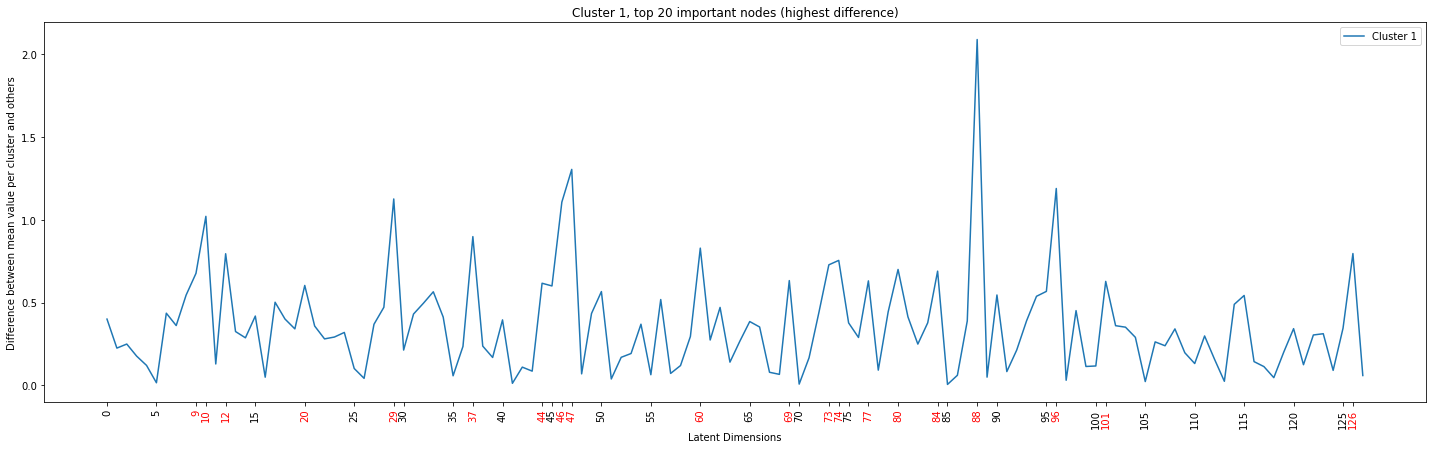

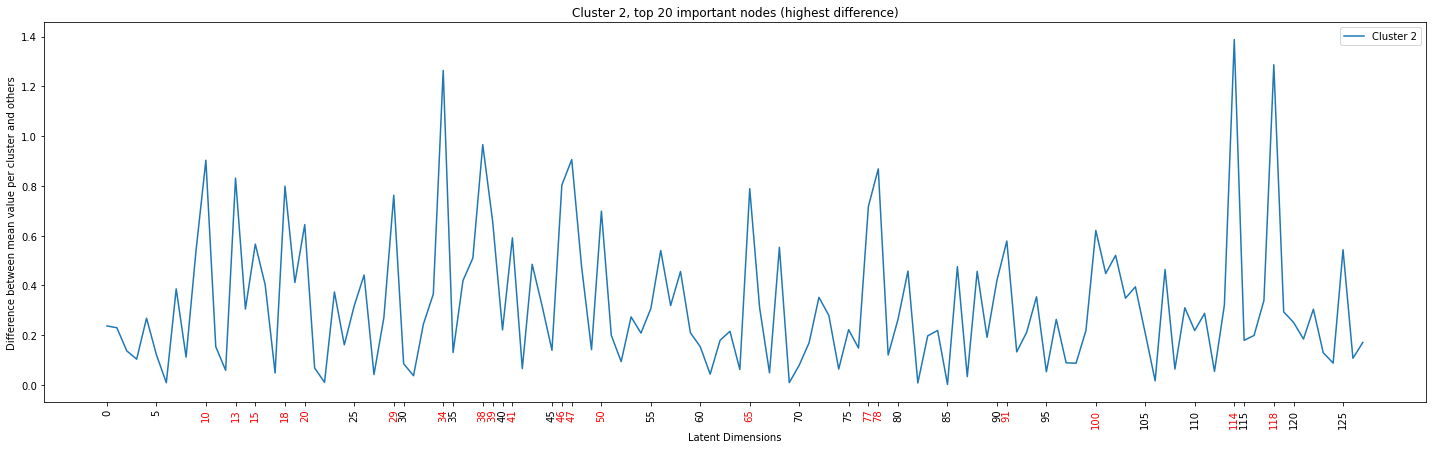

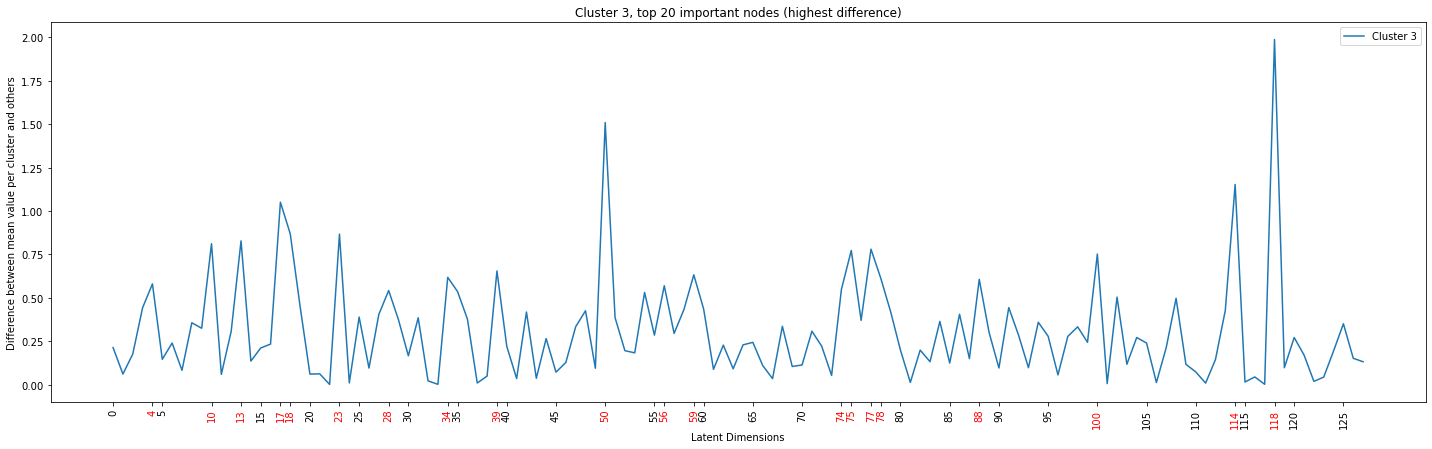

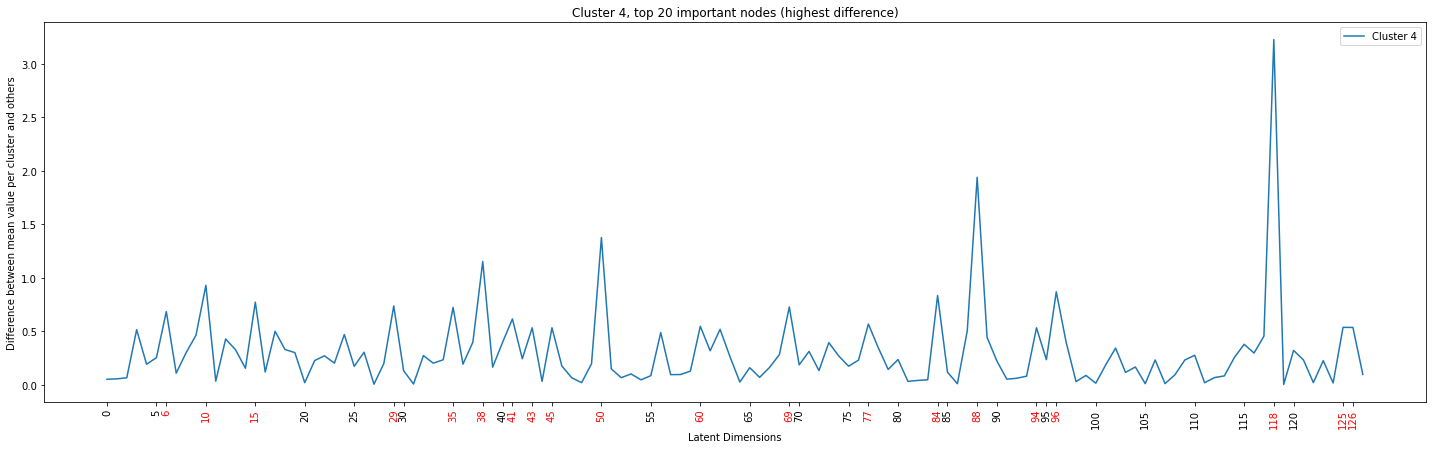

In [72]:
LSA = LatentSpaceAnalysis(clustered=t2m_thermo_clustered,
                         top_N_nodes=20)
# LSA.plot_period_means()
# LSA.plot_cluster_means()
# LSA.plot_cluster_means(DIFF=True)
LSA.plot_cluster_difference()

## losse flodders hieronder

In [42]:
LSA.heatwave_mean_of_cluster[1].shape

(128,)

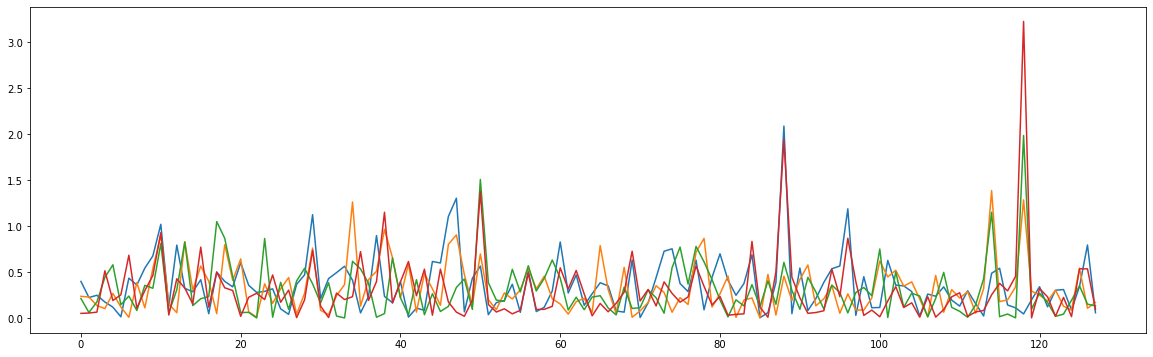

In [43]:
ks = list(np.arange(1,k+2,1))

for i, cluster_id in enumerate(ks):
    remaining = ks[:i] + ks[i+1:]
    values = LSA.heatwave_mean_of_cluster[cluster_id]
    others = []
    for j in remaining:
        others.append(LSA.heatwave_mean_of_cluster[j])
    others_mean = np.mean(np.array(others), axis=0)
    difference = abs(values - others_mean)
    plt.plot(x, difference, label=f"Cluster {i+1}")

In [8]:
both = []
all_heatwaves = []
heatwaves_1940_1970 = []
heatwaves_1990_2020 = []

for i in range(heatwave_means.shape[0]):
    year = heatwave_dates[i].year
    mean = heatwave_means.values[i, :]
    all_heatwaves.append(mean)
    if year <= 1970:
        heatwaves_1940_1970.append(mean)
        both.append(mean)
    elif year >= 1990 and year <= 2020:
        heatwaves_1990_2020.append(mean)
        both.append(mean)
        
heatwaves_1940_1970_mean = np.mean(np.array(heatwaves_1940_1970), axis=0)
heatwaves_1990_2020_mean = np.mean(np.array(heatwaves_1990_2020), axis=0)
both_collapsed = np.array(both)
all_collapsed = np.array(all_heatwaves)

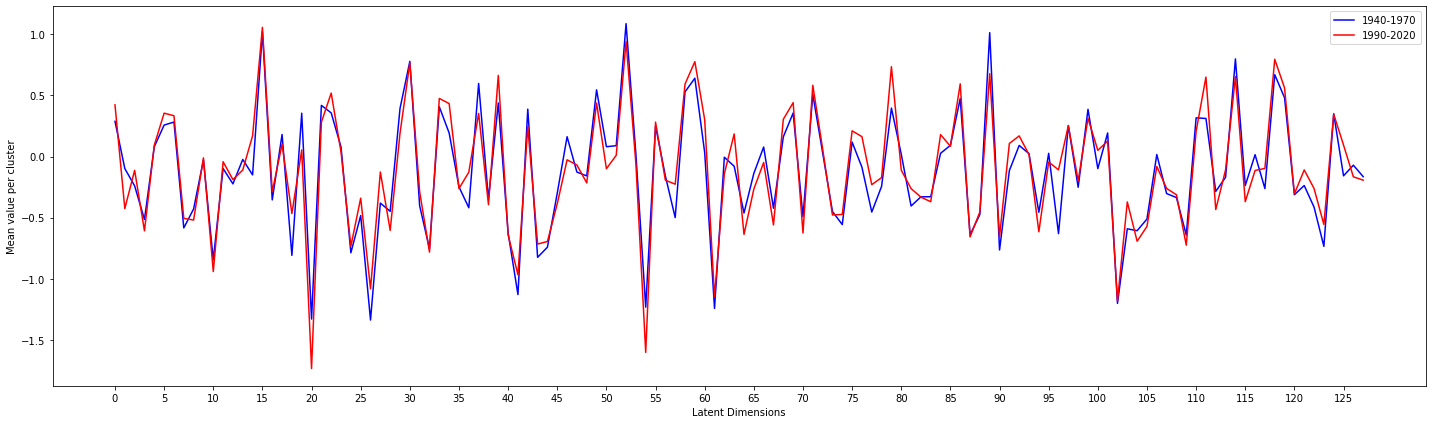

In [10]:

x=np.arange(128)
plt.plot(x, heatwaves_1940_1970_mean, label=f"1940-1970", c="b")
plt.plot(x, heatwaves_1990_2020_mean, label=f"1990-2020", c="r")



plt.xlabel("Latent Dimensions")
plt.ylabel("Mean value per cluster")
plt.legend()
plt.xticks(ticks=np.arange(0, 128, 5))  # Show every 5th label to avoid clutter
plt.tight_layout()


plt.rcParams["figure.figsize"] = (20, 6)  # width=30 inches, height=6

plt.show()


In [25]:
heatwave_clusters

(739,)

In [27]:
heatwave_means_per_cluster = {}
heatwave_mean_of_cluster = {}

for k in range(t2m_thermo_clustered.cluster_k):
    clusterID = k+1
    indices = np.where(heatwave_clusters==k)[0]
    heatwave_means_of_this_cluster = heatwave_means.to_numpy()[indices]
    heatwave_means_per_cluster[clusterID]=(heatwave_means_of_this_cluster)
    
    mean_of_cluster = np.mean(heatwave_means_of_this_cluster, axis=0)
    heatwave_mean_of_cluster[clusterID]=mean_of_cluster


In [31]:
heatwave_means_per_cluster[1].shape, heatwave_mean_of_cluster[1].shape


((221, 128), (128,))

In [23]:
heatwave_means_ID.shape

(164, 128)

In [11]:
classes = []
for k in range(t2m_thermo_clustered.cluster_k):
    clusterID = k+1
    indices = np.where(heatwave_clusters==k)[0]
    heatwave_means_ID = heatwave_means.to_numpy()[indices]
    classes.append(heatwave_means_ID)
    print(len(indices))
    print(heatwave_means_ID.shape)

221
(221, 128)
168
(168, 128)
186
(186, 128)
164
(164, 128)


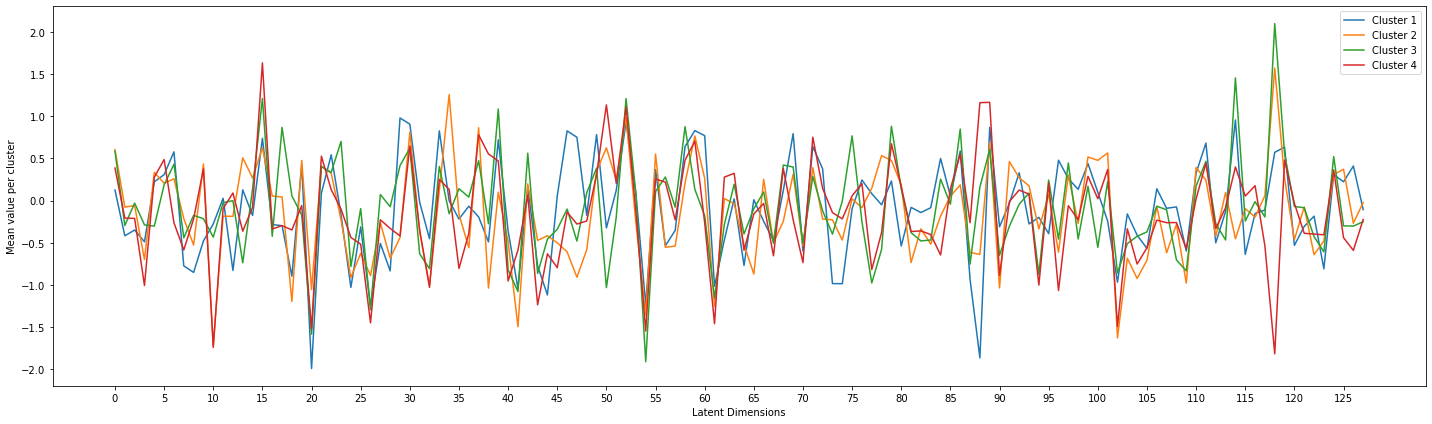

In [12]:
for i, clustergroup in enumerate(classes):
    mean = np.mean(clustergroup, axis=0)
    x=np.arange(128)
    plt.plot(x, mean, label=f"Cluster {i+1}")
    
plt.xlabel("Latent Dimensions")
plt.ylabel("Mean value per cluster")
plt.legend()
plt.xticks(ticks=np.arange(0, 128, 5))  # Show every 5th label to avoid clutter
plt.tight_layout()


plt.rcParams["figure.figsize"] = (20, 6)  # width=30 inches, height=6

plt.show()



AttributeError: 'list' object has no attribute 'shape'

In [40]:

means = {}
for i, clustergroup in enumerate(classes):
    mean = np.mean(clustergroup, axis=0)
    x=np.arange(128)
    means[i+1]=mean
    
ks = list(np.arange(1,k+2,1))

for i, cluster_id in enumerate(ks):
    remaining = ks[:i] + ks[i+1:]
    values = means[cluster_id]
    others = []
    for j in remaining:
        others.append(means[j])
    others_mean = np.mean(np.array(others), axis=0)
    difference = abs(values - others_mean)
    plt.plot(x, difference, label=f"Cluster {i+1}")
    

plt.xlabel("Latent Dimensions")
plt.ylabel("Difference between mean value per cluster and others")
plt.legend()
plt.xticks(ticks=np.arange(0, 128, 5))  # Show every 5th label to avoid clutter
plt.tight_layout()


plt.rcParams["figure.figsize"] = (20, 6)  # width=30 inches, height=6

plt.show()



AxisError: axis 0 is out of bounds for array of dimension 0

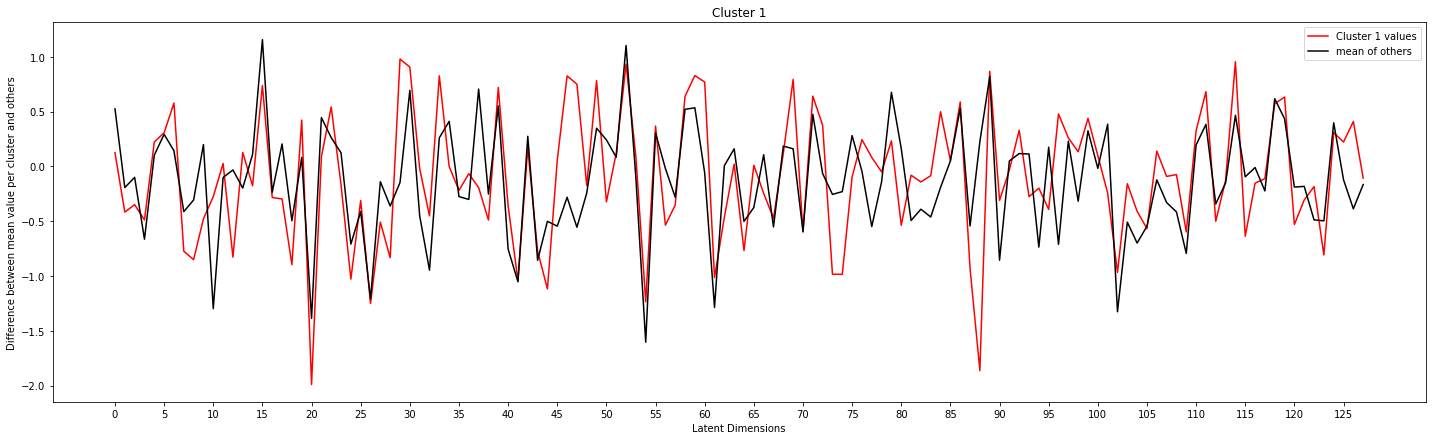

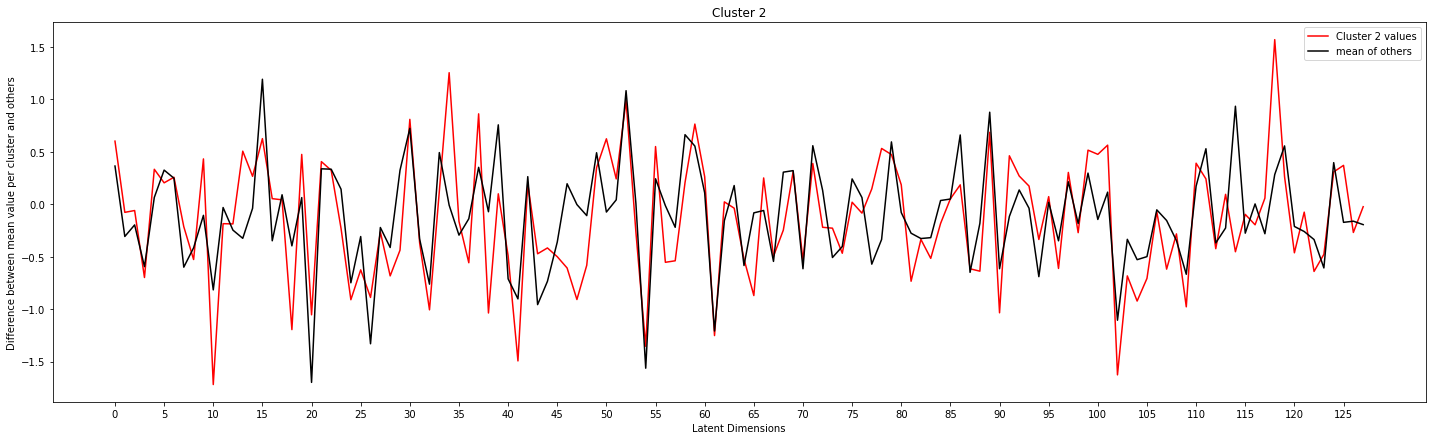

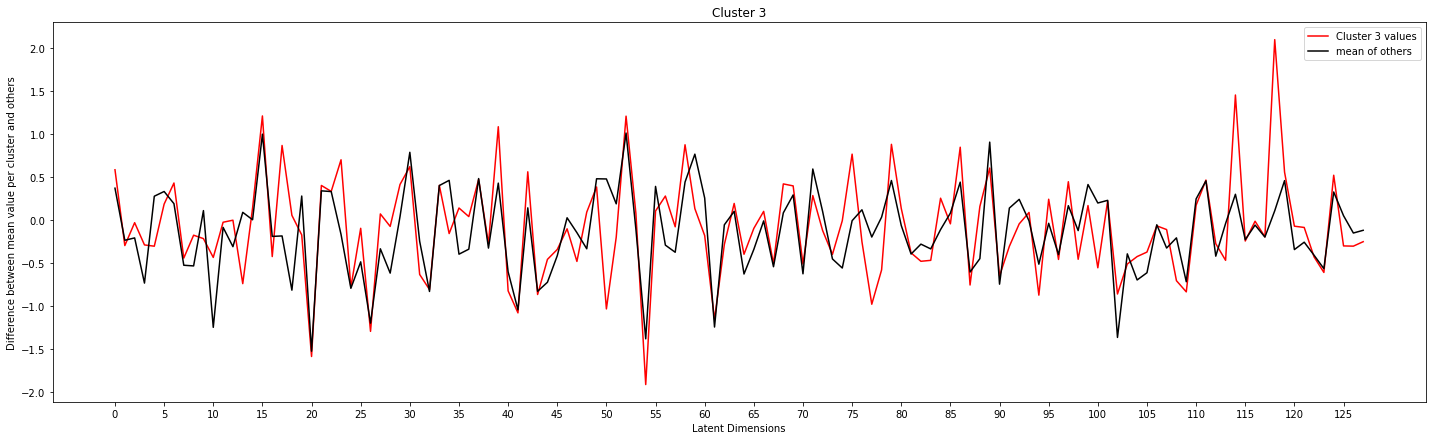

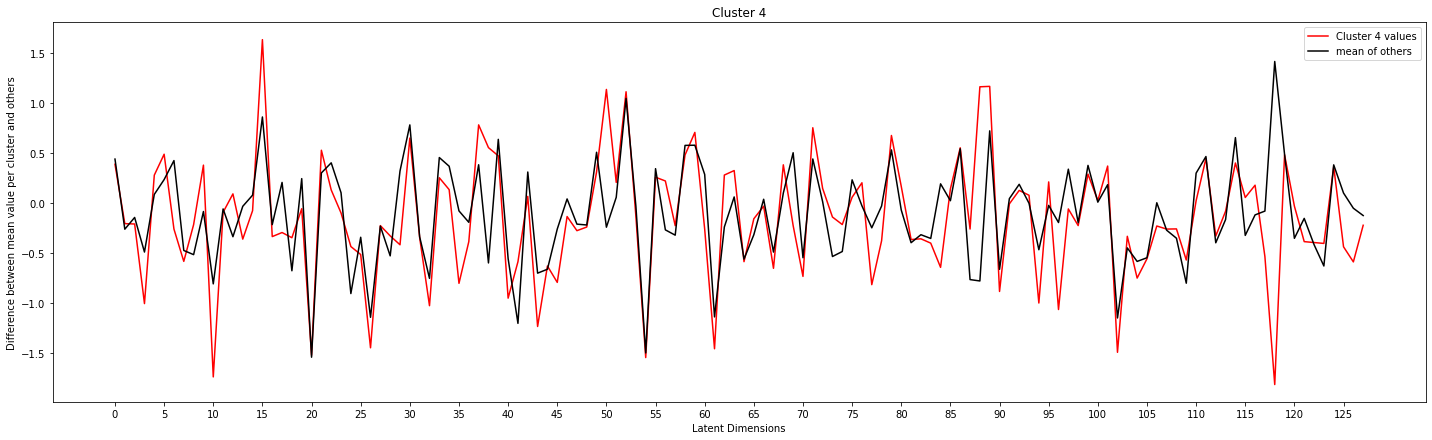

<Figure size 1440x432 with 0 Axes>

In [37]:

means = {}
for i, clustergroup in enumerate(classes):
    mean = np.mean(clustergroup, axis=0)
    x=np.arange(128)
    means[i+1]=mean
    
ks = list(np.arange(1,k+2,1))

for i, cluster_id in enumerate(ks):
    remaining = ks[:i] + ks[i+1:]
    values = means[cluster_id]
    others = []
    for j in remaining:
        others.append(means[j])
    others_mean = np.mean(np.array(others), axis=0)
    difference = abs(values - others_mean)
#     plt.plot(x, difference, label=f"Cluster {i+1}")
    plt.plot(x, values, label=f"Cluster {cluster_id} values", c="red")
    plt.plot(x, others_mean, label=f"mean of others", c="black")
    

    plt.xlabel("Latent Dimensions")
    plt.ylabel("Difference between mean value per cluster and others")
    plt.legend()
    plt.xticks(ticks=np.arange(0, 128, 5))  # Show every 5th label to avoid clutter
    plt.tight_layout()
    
    plt.title(f"Cluster {cluster_id}")


    plt.rcParams["figure.figsize"] = (20, 6)  # width=30 inches, height=6

    plt.show()
    plt.clf()



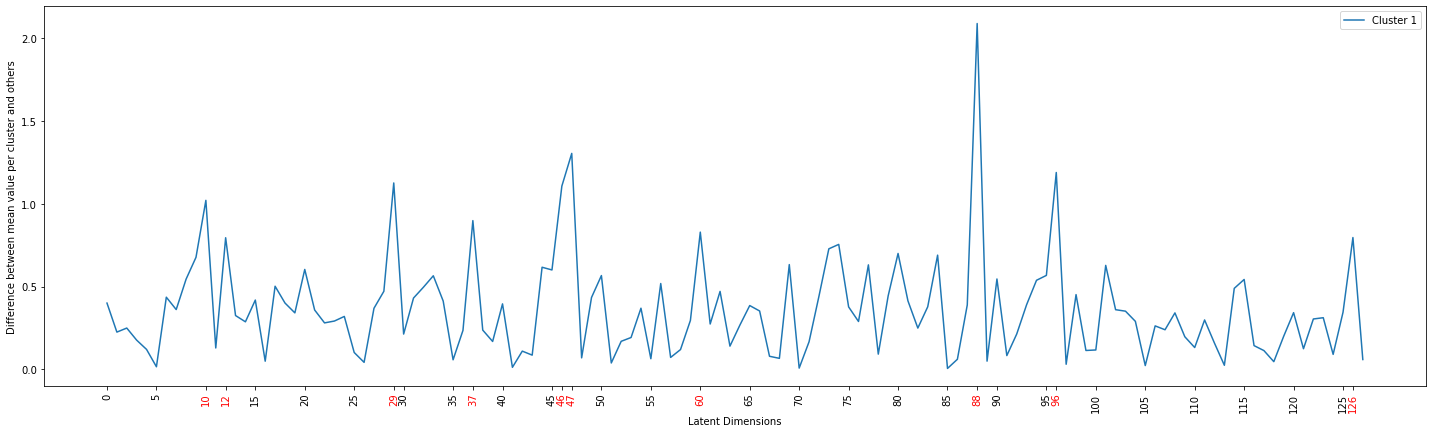

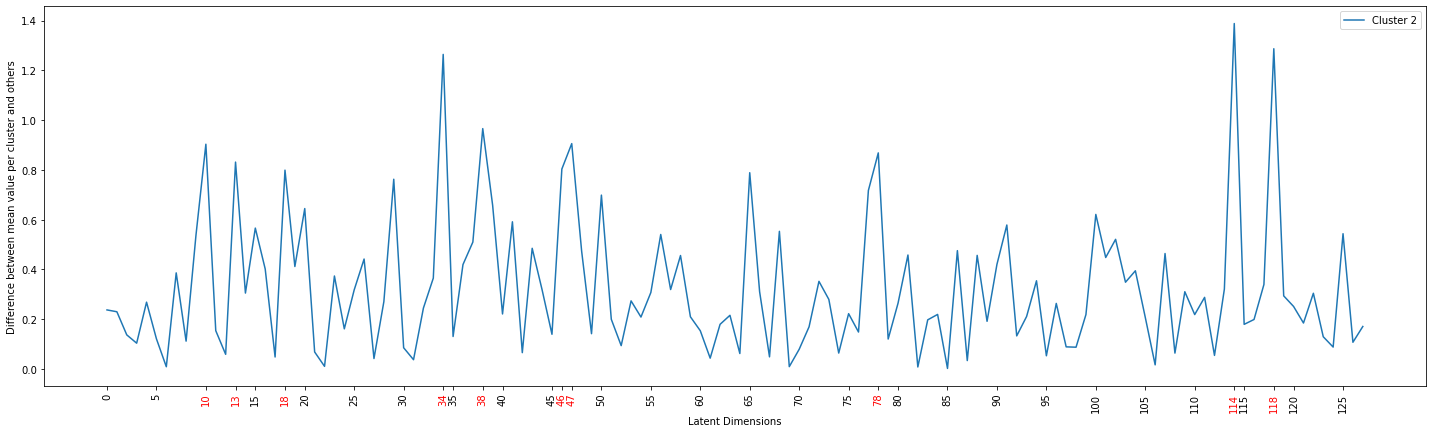

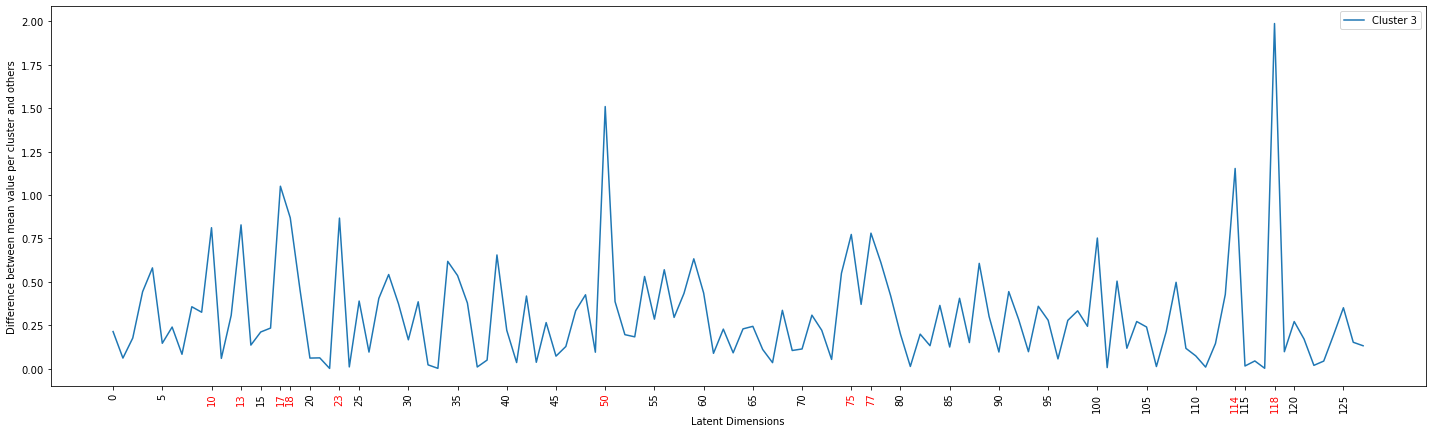

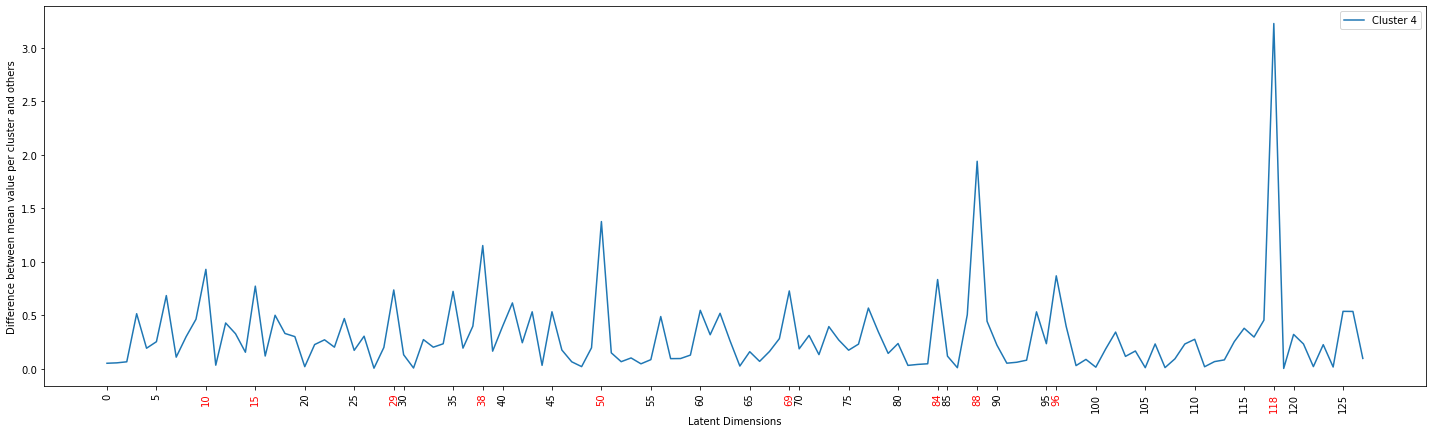

In [52]:
#identify X- most important notes




means = {}
for i, clustergroup in enumerate(classes):
    mean = np.mean(clustergroup, axis=0)
    x=np.arange(128)
    means[i+1]=mean
    
ks = list(np.arange(1,k+2,1))

nr_nodes = 10 # number of nodes of interest

for i, cluster_id in enumerate(ks):
    remaining = ks[:i] + ks[i+1:]
    values = means[cluster_id]
    others = []
    for j in remaining:
        others.append(means[j])
    others_mean = np.mean(np.array(others), axis=0)
    difference = abs(values - others_mean)
    
    top_indices = np.argsort(difference)[-nr_nodes:][::-1]

    #plot
    plt.plot(x, difference, label=f"Cluster {i+1}")
    

    plt.xlabel("Latent Dimensions")
    plt.ylabel("Difference between mean value per cluster and others")
    plt.legend()
    plt.tight_layout()

    # Default ticks every 5
    ticks = list(np.arange(0, 128, 5))

    # Ensure top_indices are included in ticks
    for idx in top_indices:
        if idx not in ticks:
            ticks.append(idx)
    ticks = sorted(ticks)

    plt.xticks(ticks=ticks)
    plt.tight_layout()

    # Highlight top indices
    ax = plt.gca()
    for tick_label in ax.get_xticklabels():
        tick_label.set_rotation(90)  # rotate labels 45 degrees

        value = int(tick_label.get_text())
        if value in top_indices:
            tick_label.set_color('red')
            tick_label.set_fontsize(10)
        else:
            tick_label.set_color('black')
            tick_label.set_fontsize(10)


    plt.rcParams["figure.figsize"] = (20, 6)  # width=30 inches, height=6

    plt.show()


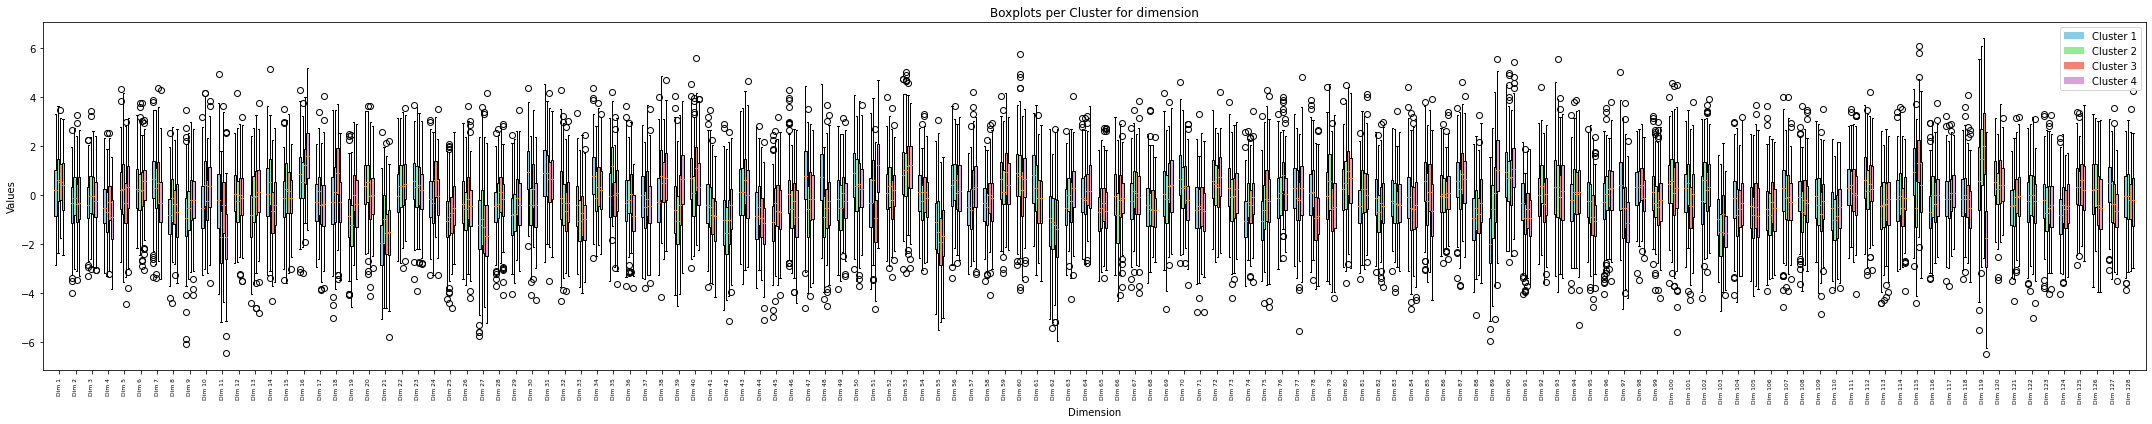

In [10]:

# Organize data into a list for iteration
all_classes = classes
num_categories = 128
num_classes = len(all_classes)

# Width of each boxplot and spacing
box_width = 0.15
spacing = 0.2  # spacing between categories

# Create positions for each class per category
positions = []
data_to_plot = []

for cat_idx in range(num_categories):
    for class_idx, cls_data in enumerate(all_classes):
        # collect data for current category and class
        data_to_plot.append(cls_data[:, cat_idx])
        # calculate position on x-axis
        pos = cat_idx + (class_idx - 1.5) * box_width
        positions.append(pos)

# Create the plot
fig, ax = plt.subplots(figsize=(30, 6))  # widen the figure to fit 128 categories

# Plot all boxplots
bp = ax.boxplot(data_to_plot, positions=positions, widths=box_width, patch_artist=True)

# Coloring each class
colors = ['skyblue', 'lightgreen', 'salmon', 'plum']
for patch, idx in zip(bp['boxes'], range(len(bp['boxes']))):
    class_idx = idx % num_classes
    patch.set_facecolor(colors[class_idx])

# Formatting
ax.set_xticks(range(num_categories))
ax.set_xticklabels([f'Dim {i+1}' for i in range(num_categories)], rotation=90, fontsize=6)
ax.set_xlim(-1, num_categories)
ax.set_title("Boxplots per Cluster for dimension")
ax.set_xlabel("Dimension")
ax.set_ylabel("Values")

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], label=f'Cluster {i+1}') for i in range(num_classes)]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# tsne


In [25]:
from openTSNE import TSNE


In [26]:
tsne = TSNE(
    perplexity=30,
    metric="euclidean",
    n_jobs=100,
    random_state=42,
    verbose=True,
)

In [29]:
both_collapsed.shape

(569, 128)

In [36]:
to_cluster = all_collapsed

%time embedding_train = tsne.fit(to_cluster)

--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, n_jobs=100, random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using exact search using euclidean distance...
   --> Time elapsed: 0.03 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.01 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.01 seconds
===> Running optimization with exaggeration=12.00, lr=61.58 for 250 iterations...
Iteration   50, KL divergence 1.0952, 50 iterations in 30.5124 sec
Iteration  100, KL divergence -1.5747, 50 iterations in 9.5826 sec
Iteration  150, KL divergence 2.9500, 50 iterations in 1.6452 sec
Iteration  200, KL divergence 2.9500, 50 iterations in 0.4102 sec
Iteration  250, KL divergence 2.9500, 50 iterations in 0.4108 sec
   --> Time elapsed: 42.56 seconds
===> Running optimization with exaggeration=1.00, lr=7

In [37]:
embedding_early = embedding_train.transform(np.array(heatwaves_1940_1970))
embedding_late = embedding_train.transform(np.array(heatwaves_1990_2020))

===> Finding 15 nearest neighbors in existing embedding using exact search...
   --> Time elapsed: 0.01 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.00 seconds
===> Running optimization with exaggeration=4.00, lr=0.10 for 0 iterations...
   --> Time elapsed: 0.00 seconds
===> Running optimization with exaggeration=1.50, lr=0.10 for 250 iterations...
Iteration   50, KL divergence 2343.2532, 50 iterations in 10.5188 sec
Iteration  100, KL divergence 2195.2106, 50 iterations in 10.0180 sec
Iteration  150, KL divergence 2163.2823, 50 iterations in 9.8428 sec
Iteration  200, KL divergence 2136.1537, 50 iterations in 9.7556 sec
Iteration  250, KL divergence 2125.0176, 50 iterations in 9.6977 sec
   --> Time elapsed: 49.83 seconds
===> Finding 15 nearest neighbors in existing embedding using exact search...
   --> Time elapsed: 0.01 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.00 seconds
===> Running optimization with exaggeration=4.00, lr=0.10 for 

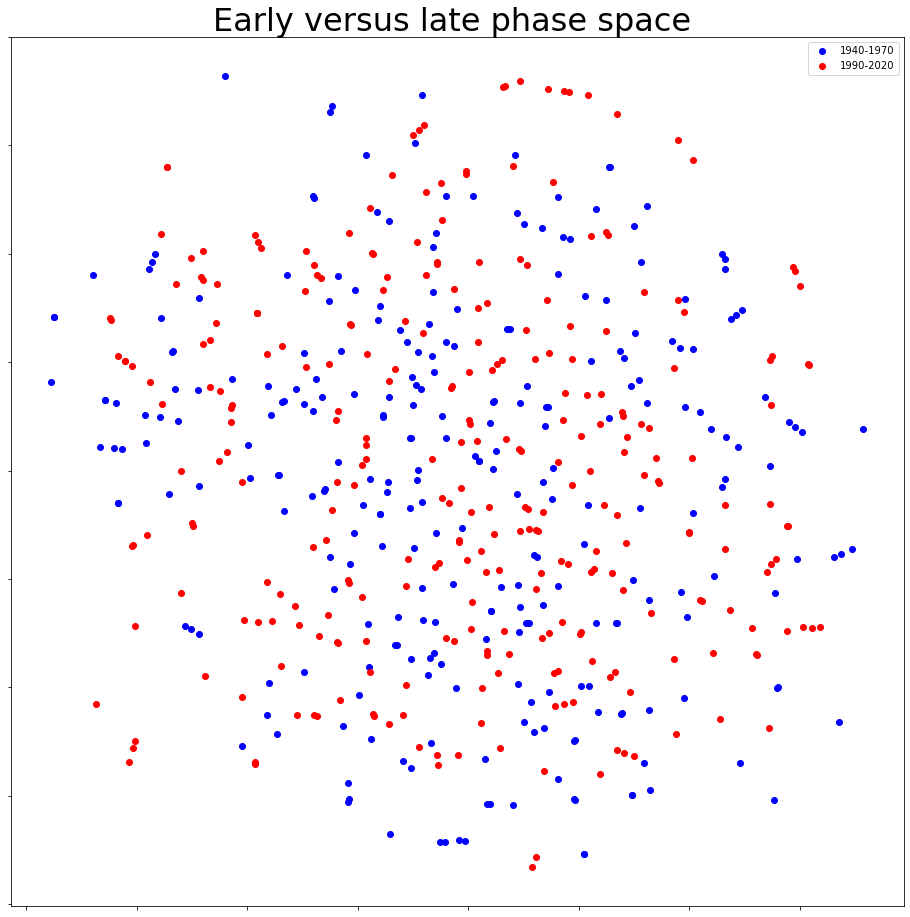

In [50]:
# plt.scatter(embedding_train[:,0], embedding_train[:,1],
#            color="black",
#            label="both")

    
plt.scatter(embedding_early[:,0], embedding_early[:,1],
           color="blue",
           label="1940-1970")

plt.scatter(embedding_late[:,0], embedding_late[:,1],
           color="red",
           label="1990-2020")


plt.tick_params(labelleft=False,labelbottom=False)    

plt.title("Early versus late phase space ", fontsize=32)
plt.legend()

plt.rcParams["figure.figsize"] = (16, 16)  # width=30 inches, height=6
plt.show()